# 2 · Model comparison

**What this notebook establishes**

1. A random split overstates PR-AUC by ~21% and collapses the fold spread 19×.
2. `days_since_last_fire` is worth +20% PR-AUC. Nothing else came close.
3. Five unrelated model families tie within the noise — an information ceiling,
   not an algorithmic one.

---

Which model family, and which features. Both answers turned out to be less interesting
than *how you measure* — so the protocol comes first.

## Two rules, both learned the hard way on this dataset

**Split by year, never randomly.** A fire burns for several days, and its cell-days are
near-duplicates. A random 5-fold split puts the same fire on both sides of the boundary,
so the model is partly scored on fires it memorised. The gap is measured below rather
than asserted.

**Fit the threshold on an inner year, never on the fold being scored.** Choosing the
best-F1 cutoff on the fold you then report is tuning on test. The inner split costs one
year of training data and buys an honest number.

A note on why this matters more than it sounds: threshold choice alone moved F1 from
0.282 to 0.50 on this data, without changing the model at all. Measurement decisions
dominated every modelling decision we tried.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd()))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from importlib import import_module
setup = import_module("00_setup")

from firerisk.evaluation import TUNED_PARAMS, cross_validate, summarise

d = setup.load_dataset()
BASE = setup.BASE_FEATURES      # 20 weather + FWI
FUEL = setup.MODEL_FEATURES     # + days_since_last_fire
FULL = setup.FEATURES           # + doy + vegetation (26)
y, years = d["label"], d["year"]
print(f"{len(d):,} rows · positives {y.mean()*100:.1f}%")

121,869 rows · positives 24.9%


## The protocol

`cross_validate` lives in [`firerisk/evaluation.py`](../src/firerisk/evaluation.py), not
here — notebook 03 has to measure the same way, and a ruler that exists in two copies is
not one ruler.

It returns per-fold metrics and out-of-fold probabilities. Each fold fits twice: once on
the training years minus an inner year to choose the threshold, then on the full training
years to score the held-out fold.

## The cost of splitting randomly

Same model, same data, one line different.

In [2]:
import lightgbm as lgb

quick = lgb.LGBMClassifier(objective="binary", n_estimators=400, learning_rate=0.05,
                           num_leaves=63, min_child_samples=40, n_jobs=-1,
                           verbose=-1, random_state=42)

grouped, _ = cross_validate(quick, d[BASE], y, years)
leaky, _ = cross_validate(quick, d[BASE], y, years, random_split=True)

gap = (leaky.pr_auc.mean() - grouped.pr_auc.mean()) / grouped.pr_auc.mean() * 100
print(f"a random split overstates PR-AUC by {gap:.0f}%")

summarise({"grouped by year (honest)": grouped, "random split (leaky)": leaky})

a random split overstates PR-AUC by 21%


,pr_auc,roc_auc,precision,recall,f1,threshold,pr_auc_sd
random split (leaky),0.5567,0.7757,0.3913,0.7952,0.5226,0.208,0.0040
grouped by year (honest),0.4594,0.7356,0.3743,0.7696,0.5019,0.204,0.0761


Look at `pr_auc_sd`, not just the mean. The collapsed spread is the real tell: random
folds all look alike because each holds fragments of the same fires, so the estimate
looks far more precise than it is. Year-grouped folds disagree because seasons genuinely
differ — and that disagreement *is* the uncertainty.

The inflated mean is the obvious problem. The fake precision is the worse one, because it
makes a fragile number look settled.

## Feature sets

`days_since_last_fire` is the one feature that mattered. It is also the easiest to turn
into a leak — see the note in `firerisk.features.add_days_since_last_fire`. Counting fires
newer than the sampling buffer makes every small value exclusively positive, because
negatives were sampled at least 4 days from any fire. That version scored **0.688** and
was pure artefact.

In [3]:
# Each rung adds one kind of information, not one column.
sets = {
    "weather only": BASE,
    "+ fuel depletion": FUEL,
    "+ seasonality (doy)": FUEL + ["doy"],
    "+ vegetation (NDVI)": FULL,
}
summarise({name: cross_validate(quick, d[f], y, years)[0] for name, f in sets.items()})

,pr_auc,roc_auc,precision,recall,f1,threshold,pr_auc_sd
+ vegetation (NDVI),0.5700,0.7891,0.4237,0.7514,0.5409,0.210,0.0923
+ seasonality (doy),0.5545,0.7771,0.4540,0.6627,0.5341,0.254,0.0842
+ fuel depletion,0.5514,0.7767,0.4646,0.6528,0.5364,0.268,0.0744
weather only,0.4594,0.7356,0.3743,0.7696,0.5019,0.204,0.0761


## Model families

Boosted trees, bagged trees, and a neural network. The network needs scaling and a log on
the fuel sentinel; the trees need neither.

In [4]:
import xgboost as xgb
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

families = {
    "LightGBM (tuned)": lgb.LGBMClassifier(**TUNED_PARAMS),
    "XGBoost": xgb.XGBClassifier(n_estimators=600, learning_rate=0.05, max_depth=7,
                                 subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                                 eval_metric="aucpr", tree_method="hist", random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                           n_jobs=-1, random_state=42),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=300, min_samples_leaf=5,
                                       n_jobs=-1, random_state=42),
    "MLP (32)": Pipeline([("scale", StandardScaler()),
                          ("net", MLPClassifier(hidden_layer_sizes=(32,), batch_size=512,
                                                max_iter=100, early_stopping=True,
                                                n_iter_no_change=8, random_state=42))]),
}

# The net needs scaling and a log on the 9999 sentinel; trees are invariant
# to both, and scaling them was measured at 0.0004 PR-AUC.
#
# LightGBM and XGBoost route NaN natively. sklearn's forests and the net do
# not, and NDVI is missing on 0.05% of rows - coastal cells that are mostly
# sea, so MODIS masks them. Those three get a median-filled copy; 60 rows
# cannot move a comparison decided at the third decimal.
X_tree = d[FULL]
X_dense = X_tree.fillna(X_tree.median())
X_net = X_dense.copy()
X_net["days_since_last_fire"] = np.log1p(X_net["days_since_last_fire"])

NEEDS_DENSE = ("RandomForest", "ExtraTrees")

results = {}
for name, model in families.items():
    if name.startswith("MLP"):
        X = X_net
    elif name in NEEDS_DENSE:
        X = X_dense
    else:
        X = X_tree
    results[name], _ = cross_validate(model, X, y, years)

summarise(results)

,pr_auc,roc_auc,precision,recall,f1,threshold,pr_auc_sd
LightGBM (tuned),0.5787,0.7938,0.4224,0.7661,0.5442,0.210,0.0892
MLP (32),0.5670,0.7839,0.4317,0.7250,0.5394,0.234,0.0827
XGBoost,0.5664,0.7865,0.4099,0.7834,0.5357,0.186,0.0897
RandomForest,0.5660,0.7816,0.4444,0.6925,0.5405,0.264,0.0936
ExtraTrees,0.5354,0.7705,0.4084,0.7579,0.5228,0.244,0.1155


## The finding that matters

Boosted trees, bagged trees and a neural network land within about **0.01 PR-AUC** of each
other, against fold-to-fold noise of roughly **±0.07**. That is a tie, not a ranking.

When three unrelated inductive biases converge, the limit is the **information in the
features**, not the algorithm. Tuning confirmed it: a 40-configuration search chose heavy
regularisation — 29 leaves, minimum 197 samples per leaf — which is what a model does when
it is fighting noise rather than finding structure.

So further model work is not where the remaining gains are. Vegetation state (NDVI) is —
the model still has no idea how much fuel is present.

,gain_%
days_since_last_fire,21.9
rh_mean,8.5
doy,7.2
fwi,6.4
dc,5.6
ndvi,5.4
ndvi_normal,5.3
ffmc,4.5
vpd_max,3.8
ndvi_change_32d,3.7


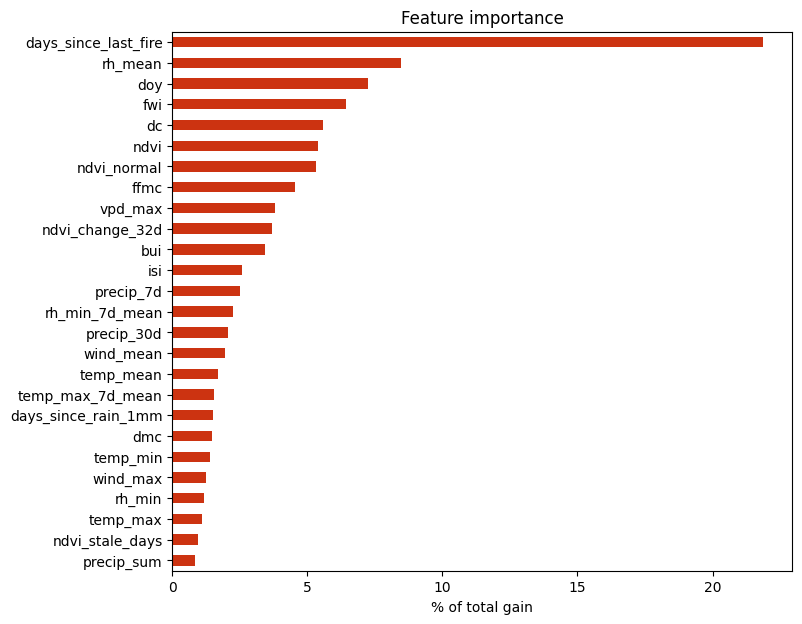

In [5]:
best = lgb.LGBMClassifier(**TUNED_PARAMS).fit(X_tree, y)
imp = pd.Series(best.booster_.feature_importance("gain"), index=FULL)
imp = (imp / imp.sum() * 100).sort_values()

ax = imp.plot(kind="barh", figsize=(8, 7), color="#cc3311")
ax.set_xlabel("% of total gain"); ax.set_title("Feature importance")

imp.sort_values(ascending=False).round(1).to_frame("gain_%").head(10)